In [7]:
import numpy as np
import matplotlib.pyplot as plt

In [47]:
T = 252
annual_mu = 0.10
annual_vol = 0.05
daily_mu = annual_mu/T
daily_vol = annual_vol/np.sqrt(T)
n_simulations = 10_000

print(daily_mu)
print(daily_vol)


0.0003968253968253968
0.00314970394174356


In [25]:
returns = np.random.normal(
        daily_mu,
        daily_vol,
        size=(n_simulations, T)
    )
# each row is one simulated year path
# each col is one trading day
# size is n_simulations * T

In [38]:
wealth = 100 * (1+returns).cumprod(axis=1)
wealth

array([[100.42801948, 100.54297962, 100.70021488, ..., 107.11334233,
        107.25773505, 107.39162345],
       [100.01560223, 100.3794892 , 100.54624382, ..., 112.05911409,
        112.09444778, 112.34515648],
       [100.25794058, 100.58668853, 100.68537794, ..., 108.59694369,
        108.52562847, 108.38476276],
       ...,
       [ 99.82964201,  99.93339494, 100.60862208, ..., 107.62184507,
        107.92625927, 107.79800462],
       [100.3235722 , 100.37471304, 100.31765222, ..., 111.44370129,
        111.21128863, 110.51389205],
       [100.50313619, 100.19221823,  99.61845425, ..., 110.2110088 ,
        110.0253526 , 109.48476028]])

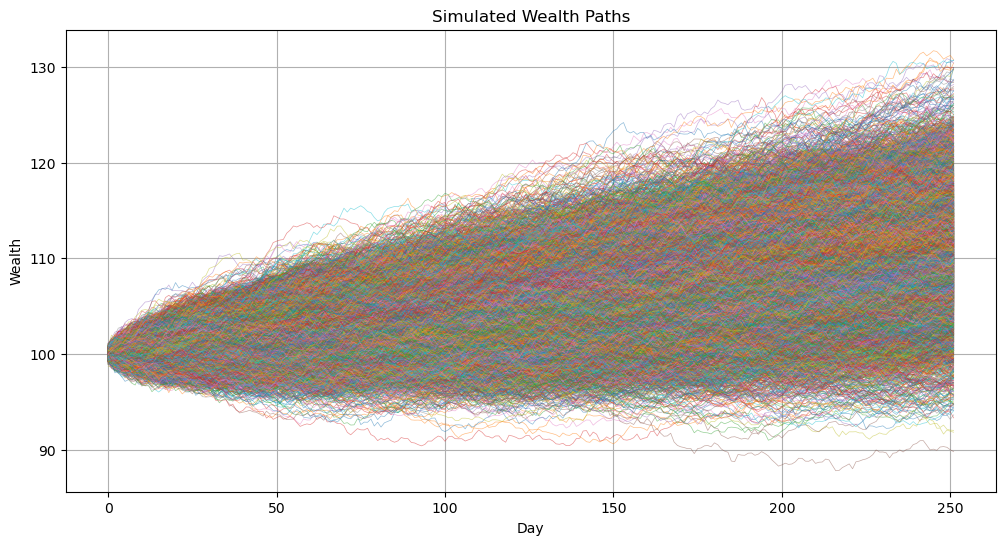

In [40]:
plt.figure(figsize=(12, 6))

plt.plot(wealth.T, alpha=0.5, linewidth=0.5)

plt.xlabel("Day")
plt.ylabel("Wealth")
plt.title("Simulated Wealth Paths")
plt.grid(True)

plt.show()

In [42]:
terminal_wealth = wealth[:, -1]
terminal_wealth

array([107.39162345, 112.34515648, 108.38476276, ..., 107.79800462,
       110.51389205, 109.48476028])

In [44]:
percentiles = np.percentile(terminal_wealth, [25, 50, 75])
print(terminal_wealth.mean())
print(percentiles)

110.48868022820481
[106.69302758 110.42162015 114.18340606]


In [51]:
T = 252

annual_mu = 0.10

daily_mu = annual_mu / T

vols = [0.05, 0.10, 0.20, 0.30, 0.50]

n_simulations = 10_000


results = []

for annual_vol in vols:

    daily_vol = annual_vol / np.sqrt(252)

    returns = np.random.normal(
        daily_mu,
        daily_vol,
        size=(n_simulations, T)
    )

    wealth = 100 * np.prod(1 + returns, axis=1)

    terminal_wealth = wealth[:-1]
    percentiles = np.percentile(terminal_wealth,[25,50,75])

    results.append({
        "vol": annual_vol,
        "mean_wealth": wealth.mean(),
        "25th percentile wealth": percentiles[0],
        "50th percentile wealth": percentiles[1],
        "75th percentile wealth": percentiles[2],
        "mean_log_growth": np.mean(
            np.sum(np.log1p(returns), axis=1)
        )
    })

In [52]:
results

[{'vol': 0.05,
  'mean_wealth': 110.49341244212594,
  '25th percentile wealth': 106.74750961150986,
  '50th percentile wealth': 110.30739420945909,
  '75th percentile wealth': 114.06837736711404,
  'mean_log_growth': 0.09856058067196323},
 {'vol': 0.1,
  'mean_wealth': 110.39147705164342,
  '25th percentile wealth': 102.60668738023193,
  '50th percentile wealth': 109.78486600872223,
  '75th percentile wealth': 117.49036222159529,
  'mean_log_growth': 0.09385104264625739},
 {'vol': 0.2,
  'mean_wealth': 110.0100953348777,
  '25th percentile wealth': 94.03133981172337,
  '50th percentile wealth': 108.01658472858723,
  '75th percentile wealth': 123.33390769069618,
  'mean_log_growth': 0.07534763519834048},
 {'vol': 0.3,
  'mean_wealth': 110.04894421787762,
  '25th percentile wealth': 85.78128983185545,
  '50th percentile wealth': 104.88137338104018,
  '75th percentile wealth': 128.11351713290043,
  'mean_log_growth': 0.05063690560623343},
 {'vol': 0.5,
  'mean_wealth': 109.5286061650696,
